# K-Means — Customer Segmentation (Industrial)

Complete clustering workflow: dataset → scaling → K selection (silhouette sampling) → profiling → PCA visualization.

_Last rebuild: **2026-02-16 01:41:36**_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


In [2]:
# Dataset (offline, realistic-ish)
N = 1200
age = np.clip(np.random.normal(38, 12, N), 18, 80)
income = np.clip(np.random.lognormal(mean=10.4, sigma=0.35, size=N), 15000, 250000)
spend = np.clip(np.random.beta(2.2, 2.0, N) * 100, 0, 100)
visits = np.clip(np.random.poisson(4, N), 0, 30)
tenure = np.clip(np.random.gamma(2.0, 18.0, N), 0, 240)
region = np.random.choice(['EU','NA','APAC'], size=N, p=[0.45,0.30,0.25])
channel = np.random.choice(['web','mobile','store'], size=N, p=[0.40,0.45,0.15])

df = pd.DataFrame({
 'age': age, 'income': income, 'spend_score': spend, 'visits_month': visits, 'tenure_months': tenure,
 'region': region, 'channel': channel
})

df.head()

,age,income,spend_score,visits_month,tenure_months,region,channel
0,43.960570,34331.843209,35.396200,1,43.725492,EU,store
1,36.340828,28274.286337,47.553071,7,46.134655,APAC,mobile
2,45.772262,34296.689966,16.616076,2,29.137199,EU,mobile
3,56.276358,39741.621189,84.685813,6,29.537012,NA,mobile
4,35.190160,33426.391266,49.108336,5,7.168683,NA,web


In [3]:
num_cols = ['age','income','spend_score','visits_month','tenure_months']
X = StandardScaler().fit_transform(df[num_cols])
X.shape

(1200, 5)

In [4]:
# K selection (silhouette is O(n^2) → sample for stability)
ks = list(range(2, 9))
scores = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels, sample_size=min(500, X.shape[0]), random_state=42)
    scores.append(s)

best_k = ks[int(np.argmax(scores))]
best_k, max(scores)

(6, 0.1620818161318089)

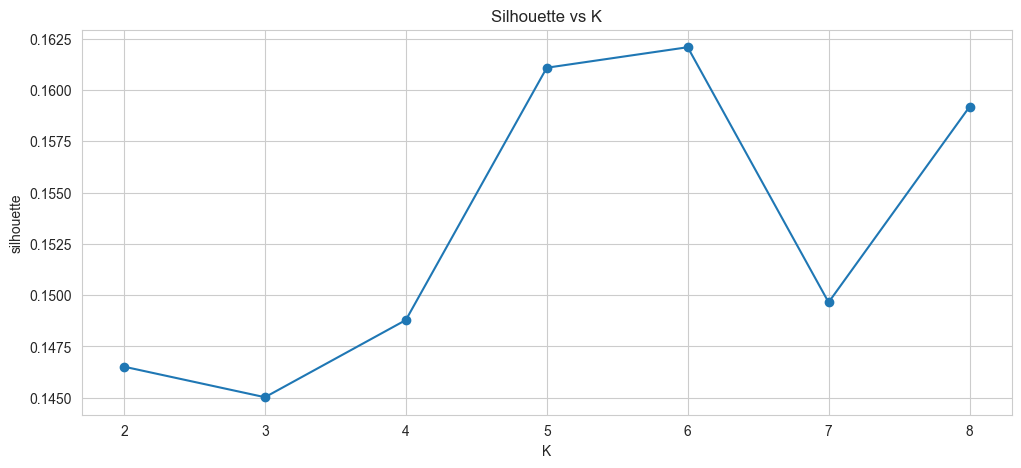

In [5]:
plt.plot(ks, scores, marker='o'); plt.title('Silhouette vs K'); plt.xlabel('K'); plt.ylabel('silhouette'); plt.show()

In [6]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df['cluster'] = km.fit_predict(X)

print(df['cluster'].value_counts().sort_index())

profile = df.groupby('cluster')[num_cols].mean().round(2)
profile

cluster
0    135
1    252
2    237
3    221
4    141
5    214
Name: count, dtype: int64


,age,income,spend_score,visits_month,tenure_months
cluster,,,,,
0,36.46,58134.24,57.36,3.19,31.93
1,34.72,29399.45,32.68,2.79,28.37
2,52.14,32687.29,61.70,3.10,28.58
3,38.65,34949.76,45.52,6.72,28.20
4,37.71,36678.24,48.68,3.93,88.45
5,30.27,29568.49,74.84,3.88,29.81


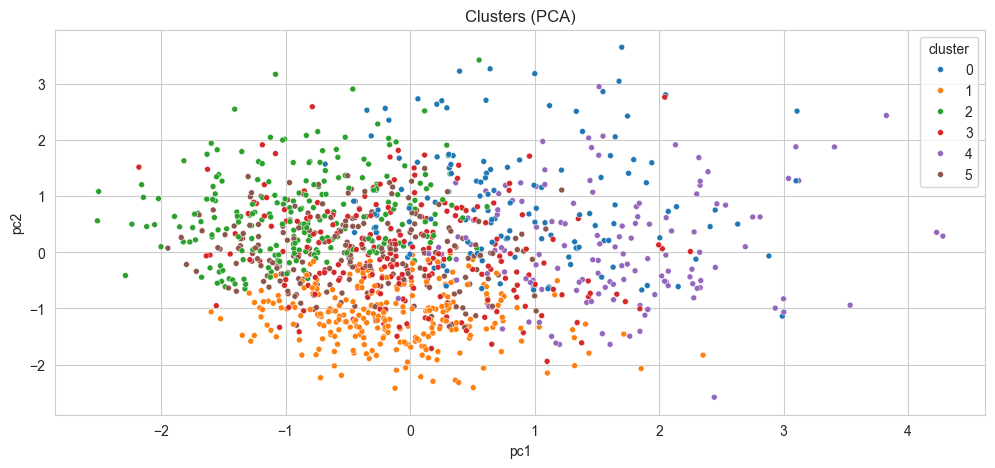

In [7]:
# PCA projection for visualization
X2 = PCA(n_components=2, random_state=42).fit_transform(X)
plot_df = pd.DataFrame({'pc1': X2[:,0], 'pc2': X2[:,1], 'cluster': df['cluster']})

sns.scatterplot(data=plot_df.sample(min(1200, len(plot_df)), random_state=42), x='pc1', y='pc2', hue='cluster', palette='tab10', s=18)
plt.title('Clusters (PCA)'); plt.show()

In [8]:
print('DONE 2026-02-16 01:41:36')

DONE 2026-02-16 01:41:36
